# 03_集成算法-梯度提升决策树（GBDT）

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇数据：`dataset/housing.csv`。

转写调整：

- 从本地 housing.csv 构造加州房价特征，删除缺失行，固定抽样 2500 行；load_local_housing(sample_size=None) 可运行全量有效数据。
- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 大规模参数网格缩为每维至多两个候选值；所有候选仍真实训练，未跳过运行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


咱们今天讲一讲集成算法 - 梯度提升决策树\~

梯度提升决策树，英文名：Gradient Boosting Decision Tree，简称 GBDT，非常重要\~

同样，先从“集成算法”说起\~

**打个比方：**你有一个问题，比如“明天下不下雨”，你不确定，就去问了十个朋友。他们可能有的说下，有的说不下，你就统计一下，大多数说啥你就信啥。这个过程就叫“集成” - **把一群人的意见整合起来，得出一个更靠谱的结论**。

在机器学习里，也一样：**集成算法就是把多个“模型”组合在一起，让它们一起“投票”或“合作”来做出更准确的预测。**

### 啥是决策树？

**决策树是个像树一样的模型，擅长做选择题。**

比如你想判断一个人是不是会买东西，决策树可能会这么问：

**他是不是年轻人？**

- 是 → 他是不是爱网购？

  - 是 → 可能会买
  - 否 → 可能不会买
- 否 → 他收入高吗？

  - 是 → 可能会买
  - 否 → 可能不会买

就像玩“20个问题”游戏一样，一步步筛选信息，最后下结论。

### 那梯度提升决策树（GBDT）是个啥？

GBDT 其实是一个“聪明的、逐步改进的决策树团队”。

先讲结论：

**梯度提升决策树就是一堆“互补”的小决策树，一个接一个地出场，每一棵都试图改正前面那些树没做好地方的错误。**

再打个比方：

1. 第一个小树（模型）上场了，它给出一个初步的预测 - 比如说猜谁会买东西，但没猜得很准。
2. 第二个小树看到这个情况，就专门来修正第一个树猜错的地方（它学的是“误差”）。
3. 第三个小树再来看看前两个树还没搞定的地方，继续修正。
4. 如此反复，一棵一棵地“接力跑”，每一棵都“朝着减少错误的方向努力” - 这就叫“梯度提升”。

你可以理解为一个团队在开会，每个人发言都试图纠正上一个人的漏洞，直到集体达成一致为止。

### 梯度是个啥意思？

“梯度”听起来高大上，其实就是“你往哪个方向走能让错误变小”，就像你在山谷里找最低点，梯度告诉你往哪走坡度是下的。

在 GBDT 里，每一棵树就是顺着这个“让错误变小的方向”走的，所以叫“**梯度**提升”。

### 总结几个点

- GBDT 是一种“集成学习”方法。
- 它集成的是一堆“小决策树”。
- 每棵树都会“纠正前一棵树犯的错”。
- 这样一棵棵修正下去，预测就越来越准。
- “梯度”就是指每一步都朝着让错误最小的方向去改进。

## 原理详解

### 1. 问题背景与目标

假设我们有一组训练数据


$$
\{(x_i, y_i)\}_{i=1}^N
$$


其中 $x_i$ 表示输入特征（可以是向量），$y_i$ 表示对应的输出（可以是连续值或分类标签）。我们的目标是构建一个模型 $F(x)$ 来预测 $y$ 值，使得整体损失（误差）最小。为此定义一个损失函数  
$L(y, F(x))$  
常见的损失函数包括均方误差（MSE）用于回归问题，指数损失（exponential loss）或者对数似然损失用于分类问题。

GBDT 的基本思路就是用**加法模型：**


$$
F(x) = F_0(x) + \sum_{m=1}^M h_m(x)
$$


其中 $h_m(x)$ 是第 $m$ 棵决策树（基学习器）。算法的核心在于如何迭代地构造每一棵树 $h_m(x)$，使得整体模型逐步逼近目标函数。

### 2. 梯度提升的基本思想

#### 拟合残差（pseudo-residual）

假设当前模型为 $F_{m-1}(x)$，此时模型的预测误差为  
$L(y, F_{m-1}(x))$  
直观想法是构造一个新的模型 $h_m(x)$ 来修正这些误差。梯度提升的关键在于利用梯度下降的思想：

计算损失函数关于预测值的负梯度（也叫伪残差），即：


$$
r_{im} = -\left[ \frac{\partial L(y_i, F(x_i))}{\partial F(x_i)} \right]_{F(x)=F_{m-1}(x)}
$$


负梯度表示如果沿着这个方向调整预测，可以减少损失。对每个数据点 $i$ 都计算一个残差 $r_{im}$。

#### 用基学习器拟合梯度残差

接下来，将基学习器（决策树）$h_m(x)$ 去拟合上面计算得到的残差 $\{r_{im}\}$：

也就是说，我们令 $h_m(x) \approx r_{im}$ ，从而使得新加入的模型能够修正之前模型的不足。

### 3. 数学推导与公式

#### 初始模型

通常从一个简单的初始模型 $F_0(x)$ 开始。对于回归问题，$F_0(x)$ 常取所有数据 $y_i$ 的均值：


$$
F_0(x) = \arg\min_\gamma \sum_{i=1}^N L(y_i, \gamma)
$$


例如，对于平方误差损失 $L(y, F(x))=\frac{1}{2}(y-F(x))^2$，


$$
F_0(x) = \frac{1}{N}\sum_{i=1}^N y_i
$$


#### 迭代更新

对于每一轮 $m = 1, 2, \dots, M$：

**1. 计算负梯度（伪残差）：**


$$
r_{im} = -\left[ \frac{\partial L(y_i, F(x_i))}{\partial F(x_i)} \right]_{F(x)=F_{m-1}(x)}
$$


这个计算反映了局部误差在每个点处的“最陡下降方向”。

**2. 拟合基学习器**：

利用决策树去拟合数据点 $\{(x_i, r_{im})\}$。假设构造一棵树后将输入空间划分为 $J_m$ 个叶子节点，每个叶子节点对应一个区域 $R_{jm}$，并且树在叶节点上的输出是常数值。这样模型形式为：


$$
h_m(x) = \sum_{j=1}^{J_m} b_{jm} \cdot \mathbf{1}(x \in R_{jm})
$$


其中 $\mathbf{1}(\cdot)$ 是指示函数，$b_{jm}$ 是在区域 $R_{jm}$ 上的预测值。

**3. 求最优步长（区域权重）**：

对每个叶子区域 $R_{jm}$，需要确定一个最佳的权重（步长）$\gamma_{jm}$使得更新后损失最小：


$$
\gamma_{jm} = \arg\min_\gamma \sum_{x_i \in R_{jm}} L(y_i, F_{m-1}(x_i) + \gamma)
$$


对于平方损失，这一步能解析求解，对于其他损失函数通常需要数值方法。

**4. 更新模型**：

采用步长因子 $\nu$（学习率，一般 $0 < \nu \leq 1$），模型更新为：


$$
F_m(x) = F_{m-1}(x) + \nu \sum_{j=1}^{J_m} \gamma_{jm} \cdot \mathbf{1}(x \in R_{jm})
$$


这样累加的模型逐步修正前面预测的不足。

### 4. 算法流程总结

整个 GBDT 算法流程可总结为以下步骤：

**1. 初始化模型**：


$$
F_0(x) = \arg\min_\gamma \sum_{i=1}^N L(y_i, \gamma)
$$


**2. for** $m=1$ **to** $M$ **迭代（总共构造** $M$ **棵树）**：

1. 对所有样本，计算伪残差：  
$r_{im} = -\left[ \frac{\partial L(y_i, F(x_i))}{\partial F(x_i)} \right]_{F(x)=F_{m-1}(x)}$
2. 拟合一棵决策树 $h_m(x)$ 到数据 $\{(x_i, r_{im})\}$，将数据划分成若干叶子节点 $\{R_{jm}\}_{j=1}^{J_m}$。
3. 对于每个叶子节点 $R_{jm}$，求解：  
$\gamma_{jm} = \arg\min_\gamma \sum_{x_i \in R_{jm}} L(y_i, F_{m-1}(x_i) + \gamma)$
4. 更新模型：  
$F_m(x) = F_{m-1}(x) + \nu \sum_{j=1}^{J_m} \gamma_{jm} \cdot \mathbf{1}(x \in R_{jm})$

**3. 输出最终模型**：


$$
F(x) = F_M(x)
$$


**加法模型构建**：GBDT 是一种加法模型，每一棵树都在先前模型的基础上添加一个新的修正项，类似于“不断累积修正”的过程。

**梯度方向指引**：通过计算损失函数的负梯度，可以明确如何调整输出使得整体模型误差下降，这与梯度下降法寻找最低点的思想是一致的。

**弱学习器的组合**：个体决策树本身可能较弱，但经过多次迭代，每个树都针对前面遗漏的误差进行修正，最终整体模型的效果远超单棵树。

### 6. 理论细节与常见变体

#### 关于损失函数

- **回归问题**：常选用均方误差（MSE）  
$L(y, F(x)) = \frac{1}{2}(y - F(x))^2$  
对于 MSE，其梯度和求解步长可以直接得到解析解。
- **分类问题**：常使用对数损失（Logistic loss）等。对于二分类问题：  
$L(y, F(x)) = \log(1 + \exp(-2yF(x)))$  
（其中 $y \in \{-1, 1\}$）  
这种情况下梯度和步长的求解可能需要数值迭代方法。

#### 学习率（Shrinkage）

引入学习率 $\nu$可以有效防止过拟合，每次更新只“迈出一小步”。较小的 $\nu$通常需要更大的 $M$ 来达到较低的误差，但能让每一步更平滑、稳定。

#### 正则化与剪枝

- 为防止模型过于复杂（过拟合），常在每棵树上加上剪枝操作或者限制树的最大深度、最小样本数。
- 同时还可能加入对叶子节点数目的正则化惩罚。

总的来说，梯度提升决策树（GBDT）利用加法模型的思想，通过迭代地构建决策树，每一步都沿着当前损失函数的负梯度方向前进，来不断地“纠正”前一步的预测错误。

其主要流程分为以下几步：

1. 初始化一个简单模型 $F_0(x)$
2. 迭代 $M$ 次，每次：

   - 根据当前模型计算伪残差（负梯度）
   - 用一棵决策树拟合这些残差，将特征空间分区，得到各区域的常数输出
   - 求解每个区域的最优更新量 $\gamma$
   - 更新模型：累加学习率调整后的新树输出
3. 得到最终的综合预测模型

这种方法通过不断逼近真实目标函数，使得模型逐步优化，不仅灵活而且具有很好的泛化能力，是目前广泛应用的一种集成学习算法。

## 完整案例

这里，选用了加州房价数据集（California Housing Dataset），并对模型进行了超参数调优、交叉验证，并通过多种可视化手段展示了模型的训练过程、残差分布以及特征重要性。

加载数据集...
数据集特征： ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
样本数：2500，特征数：8
训练样本数：1750，测试样本数：750

目标变量描述统计：
count    2500.000000
mean        2.052205
std         1.163526
min         0.367000
25%         1.191500
50%         1.760000
75%         2.642500
max         5.000010
Name: MedHouseVal, dtype: float64


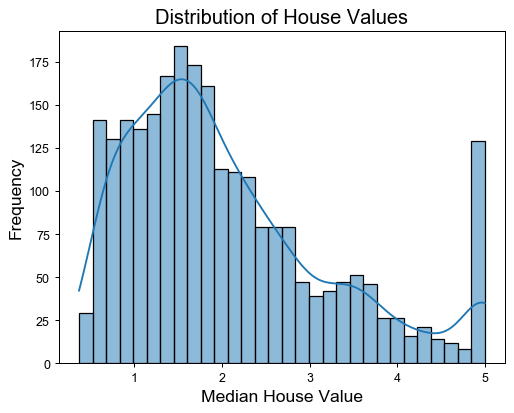

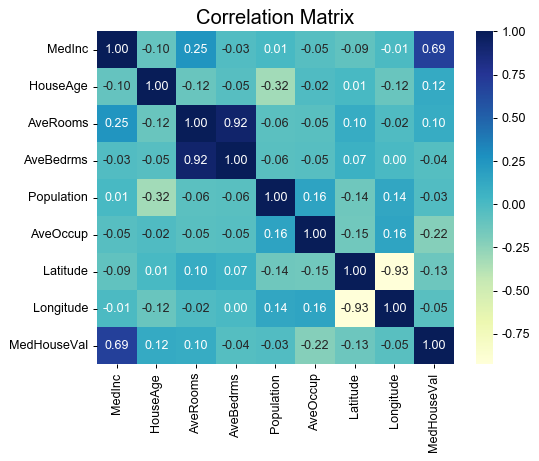


开始构建初步 GBDT 模型...


初步模型训练时间: 0.230 秒

初步模型评估结果：
Mean Squared Error (MSE): 0.3218
Mean Absolute Error (MAE): 0.3912
R^2 Score: 0.7456


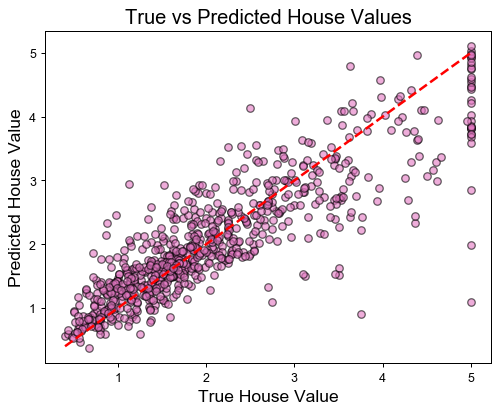

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time


# 导入数据集和模型相关库
from notebook_support import load_local_housing
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 一、数据加载与预处理
print("加载数据集...")
# 加载加州房价数据集
cal_housing = load_local_housing(as_frame=True)
X = cal_housing.data
y = cal_housing.target

# 数据集描述
print("数据集特征：", X.columns.tolist())
print("样本数：{}，特征数：{}".format(X.shape[0], X.shape[1]))

# 将数据分割为训练集和测试集（70%训练，30%测试）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print("训练样本数：{}，测试样本数：{}".format(X_train.shape[0], X_test.shape[0]))

# 二、初步数据探索性分析（Exploratory Data Analysis, EDA）
# 分析目标变量的基本统计信息
print("\n目标变量描述统计：")
print(y.describe())

# 绘制目标变量的分布直方图
plt.figure()
sns.histplot(y, bins=30, color="#1f77b4", kde=True)
plt.xlabel("Median House Value", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.title("Distribution of House Values", fontsize=16)
plt.show()

# 分析各个特征与目标变量之间的相关性
corr_matrix = pd.concat([X, y], axis=1).corr()
plt.figure()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Correlation Matrix", fontsize=16)
plt.show()
# 图中颜色越深表示相关性越高。其中某些特征（如MedInc）与房价中位数呈现明显正相关，
# 此信息可帮助后续模型解释和特征工程。

# 三、使用 Gradient Boosting Regressor 进行初步模型训练与评估
print("\n开始构建初步 GBDT 模型...")
# 初始化 GBM 模型，参数使用默认配置
gbdt = GradientBoostingRegressor(random_state=42)
start_time = time.time()
gbdt.fit(X_train, y_train)
train_time = time.time() - start_time
print("初步模型训练时间: {:.3f} 秒".format(train_time))

# 在测试集上预测
y_pred = gbdt.predict(X_test)

# 计算评价指标：均方误差 (MSE)、平均绝对误差 (MAE) 和 R^2 分数
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n初步模型评估结果：")
print("Mean Squared Error (MSE): {:.4f}".format(mse))
print("Mean Absolute Error (MAE): {:.4f}".format(mae))
print("R^2 Score: {:.4f}".format(r2))

# 可视化预测与真实值的散点图
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.6, color="#e377c2", edgecolor="k")
plt.xlabel("True House Value", fontsize=14)
plt.ylabel("Predicted House Value", fontsize=14)
plt.title("True vs Predicted House Values", fontsize=16)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
plt.show()


开始超参数调优...
Fitting 5 folds for each of 16 candidates, totalling 80 fits


最佳参数： {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
最佳得分 (MSE, negated): -0.3054


优化后模型训练时间: 0.617 秒

优化后模型评估结果：
Mean Squared Error (MSE): 0.2964
Mean Absolute Error (MAE): 0.3713
R^2 Score: 0.7657


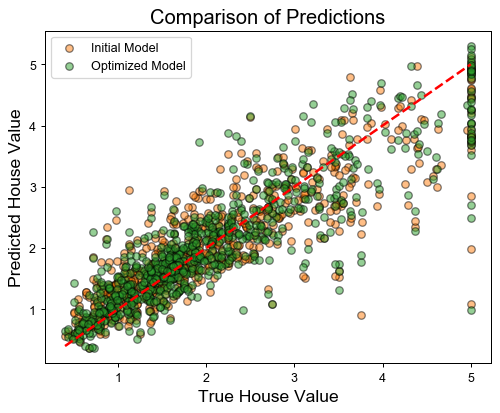

In [3]:
# 初步模型能给出较好的预测效果，但依然存在一定偏差。通过该散点图，
# 可以看到大部分数据点均分布在对角线附近，表示预测值与真实值较为接近，但也存在部分异常误差。

# 四、超参数调优与算法优化
# 为提升模型性能，进一步使用 GridSearchCV 对模型超参数进行调优，
# 主要调参项包括树的个数（n_estimators），学习率（learning_rate），最大深度（max_depth）等。
print("\n开始超参数调优...")

# 定义调参范围
param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5],
    "subsample": [0.8, 1.0]  # 引入 subsample 参数以防止过拟合，采用随机抽样
}

# 初始化 GBM 模型（优化时仍需要设置 random_state 保证结果复现）
gbdt_opt = GradientBoostingRegressor(random_state=42)

# 使用 GridSearchCV 进行 5 折交叉验证
grid_search = GridSearchCV(estimator=gbdt_opt,
                           param_grid=param_grid,
                           cv=5,
                           scoring="neg_mean_squared_error",
                           n_jobs=1,  # 使用所有处理器核心
                           verbose=1, error_score='raise')
grid_search.fit(X_train, y_train)

print("最佳参数：", grid_search.best_params_)
print("最佳得分 (MSE, negated): {:.4f}".format(grid_search.best_score_))

# 使用最佳参数构造模型
best_gbdt = grid_search.best_estimator_
start_time = time.time()
best_gbdt.fit(X_train, y_train)
opt_train_time = time.time() - start_time
print("优化后模型训练时间: {:.3f} 秒".format(opt_train_time))

# 在测试集上预测并计算指标
y_opt_pred = best_gbdt.predict(X_test)
opt_mse = mean_squared_error(y_test, y_opt_pred)
opt_mae = mean_absolute_error(y_test, y_opt_pred)
opt_r2 = r2_score(y_test, y_opt_pred)

print("\n优化后模型评估结果：")
print("Mean Squared Error (MSE): {:.4f}".format(opt_mse))
print("Mean Absolute Error (MAE): {:.4f}".format(opt_mae))
print("R^2 Score: {:.4f}".format(opt_r2))

# 可视化优化前后模型预测效果的对比
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.5, color="#ff7f0e", label="Initial Model", edgecolor="k")
plt.scatter(y_test, y_opt_pred, alpha=0.5, color="#2ca02c", label="Optimized Model", edgecolor="k")
plt.xlabel("True House Value", fontsize=14)
plt.ylabel("Predicted House Value", fontsize=14)
plt.title("Comparison of Predictions", fontsize=16)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
plt.legend()
plt.show()

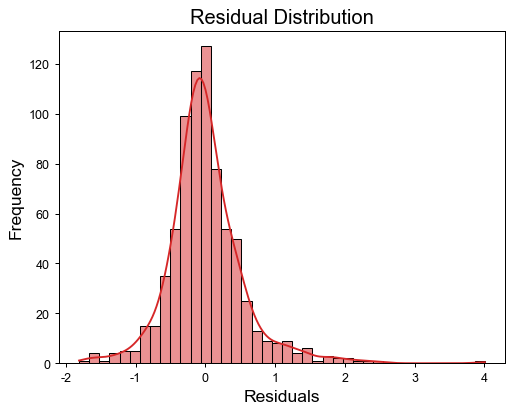

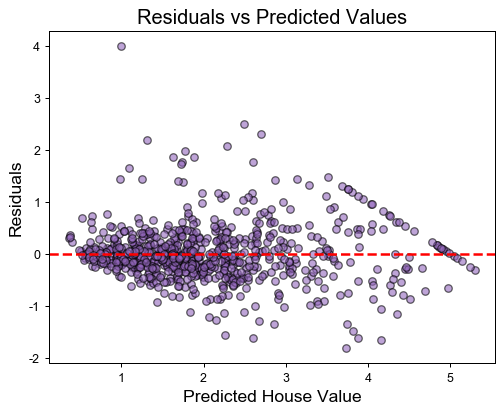

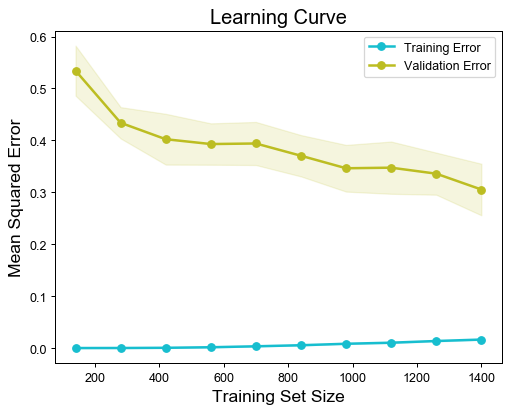

/var/folders/q6/v6bs8gb12gd1lh35j2b7z3sc0000gn/T/ipykernel_11477/414614363.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=fi_df, palette="viridis")


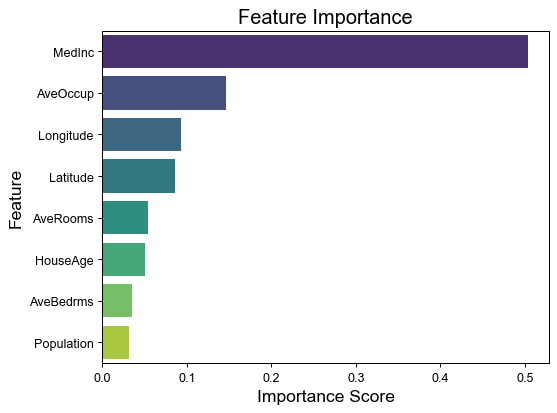

In [4]:
# 通过超参数调优，优化模型（Optimized Model）相比初步模型预测精度更高。
# 调整的超参数包括树的数目、学习率、最大深度及采样比例，其中最佳参数的选择使模型效果在交叉验证中表现出更低的均方误差。
# 上述对比图能直观显示出两种模型预测值与真实值的接近程度改进情况。

# 五、残差分析与学习曲线可视化
# 残差分析可以帮助我们了解模型的拟合情况和可能的异常点，
# 学习曲线展示模型在训练集和测试集上的误差随训练样本数的变化趋势。
# 计算优化后模型的残差：预测值和真实值之间的差值
residuals = y_test - y_opt_pred

plt.figure()
sns.histplot(residuals, bins=40, kde=True, color="#d62728")
plt.xlabel("Residuals", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.title("Residual Distribution", fontsize=16)
plt.show()

# 散点图展示残差与预测值的关系，判断是否存在系统性偏差
plt.figure()
plt.scatter(y_opt_pred, residuals, alpha=0.6, color="#9467bd", edgecolor="k")
plt.xlabel("Predicted House Value", fontsize=14)
plt.ylabel("Residuals", fontsize=14)
plt.title("Residuals vs Predicted Values", fontsize=16)
plt.axhline(y=0, color="r", linestyle="--", lw=2)
plt.show()

# 学习曲线的绘制（基于交叉验证）
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 10)):
    """
    绘制学习曲线函数
    参数：
        estimator: 模型
        X, y: 数据
        cv: 交叉验证折数
        train_sizes: 训练集比例
    """
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, train_sizes=train_sizes, scoring="neg_mean_squared_error", n_jobs=1)

    # 均值与标准差
    train_scores_mean = -np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = -np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.figure()
    plt.plot(train_sizes, train_scores_mean, "o-", color="#17becf", label="Training Error", lw=2)
    plt.plot(train_sizes, test_scores_mean, "o-", color="#bcbd22", label="Validation Error", lw=2)
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.15, color="#17becf")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.15, color="#bcbd22")
    plt.xlabel("Training Set Size", fontsize=14)
    plt.ylabel("Mean Squared Error", fontsize=14)
    plt.title("Learning Curve", fontsize=16)
    plt.legend()
    plt.show()

# 绘制优化后模型的学习曲线
plot_learning_curve(best_gbdt, X_train, y_train, cv=5)
# 残差直方图（Residual Distribution）展示了预测残差的大致分布情况，应呈现接近正态分布；而残差与预测值散点图（Residuals vs Predicted Values）则可以检查模型是否存在非线性拟合不足的迹象。
# 学习曲线则帮助我们观察随着训练集样本数增加，训练误差与验证误差的变化趋势，
# 如果二者趋于收敛，则说明模型具有较好的泛化能力；若二者间隔较大，则可能存在过拟合或欠拟合问题。

# 六、特征重要性分析与可视化
# 梯度提升树能自动给出各个特征的重要性分数。
# 这里绘制特征重要性图，让我们直观了解哪些特征对预测有最大影响。
feature_importance = best_gbdt.feature_importances_
features = X.columns
fi_df = pd.DataFrame({"Feature": features, "Importance": feature_importance})
fi_df = fi_df.sort_values("Importance", ascending=False)

plt.figure()
sns.barplot(x="Importance", y="Feature", data=fi_df, palette="viridis")
plt.xlabel("Importance Score", fontsize=14)
plt.ylabel("Feature", fontsize=14)
plt.title("Feature Importance", fontsize=16)
plt.show()

#### 1. 数据加载与预处理

首先，我们利用 `load_local_housing` 函数加载加州房价数据集。数据集包含 8 个特征（如房屋所在地区中位收入 MedInc、平均房间数 AveRooms 等）和目标变量（房价中位数）。数据集经过分割后形成训练集和测试集，保证模型能在未见数据上进行评估。此部分代码对数据的基本描述、特征名称以及样本数量进行输出，并利用直方图与热力图对目标变量和各特征相关性做初步探索。

- **直方图**：展示了房价中位数的分布情况，帮助我们判断数据是否存在偏态分布。
- **热力图**：通过各特征与目标值之间的相关系数展示，帮助发现潜在的重要特征，例如 MedInc 与房价中位数之间的强正相关，为后续特征选择和模型解释提供依据。

![原文参考图，当前结果见代码输出](attachments/img_023.png)

![原文参考图，当前结果见代码输出](attachments/img_024.png)

#### 2. 初步模型建立与评估

在构建初步模型时，直接实例化 `GradientBoostingRegressor` 并进行训练。训练完成后，在测试集上预测房价，通过计算 MSE（均方误差）、MAE（平均绝对误差）以及 R^2 分数对模型进行定量评估。同时通过散点图展示预测值与真实值的对比，其中红色虚线代表理想情况下二者完全相等的情况。

**散点图**：图中数据点集中在对角线附近说明模型预测较为理想，但部分偏离提醒后续有进一步优化空间。

![原文参考图，当前结果见代码输出](attachments/img_025.png)

#### 3. 超参数调优与算法优化

超参数调优是提升模型性能的重要步骤。

代码中利用 `GridSearchCV` 对模型中的几个关键超参数进行了组合搜索：

- **n_estimators**：树的个数，直接决定了模型的复杂度和拟合能力；
- **learning_rate**：控制每棵树对最终结果的贡献，太大容易过拟合，太小则需要更多树；
- **max_depth**：决策树的最大深度，深度越大建模能力越强，但容易过拟合；
- **subsample**：控制是否进行采样，为 1 时表示用所有样本，低于 1 时则采用随机抽样，有助于降低方差。

通过 5 折交叉验证得到最佳超参数组合后，新模型在测试集上取得了更优的评价指标。之后在一张对比图中，同时绘制了初步模型与优化模型的预测效果，能够直观对比出超参数调优后模型的明显改进。

#### 4. 残差分析与学习曲线

残差分析是判断模型是否存在系统性误差的重要手段。代码中通过直方图展示残差分布，理论上理想残差应接近正态分布；并利用散点图展示预测值与残差之间的关系，如是否存在非线性残差模式或偏离零值的现象，从而判断模型拟合是否充分。

**学习曲线**：通过交叉验证计算不同训练集规模下的训练误差和验证误差变化趋势，帮助判断模型是否存在欠拟合或过拟合现象，以及增加数据后能否进一步提升模型性能。

#### 5. 特征重要性分析

特征重要性分析能够告诉我们各个输入特征对模型输出的影响程度。通过 `best_gbdt.feature_importances_` 得到每个特征的重要性得分，并利用条形图进行展示。图中显示 MedInc 对房价预测起到主导作用，其它特征次之。该信息对解释模型预测原因及进一步数据预处理或特征工程都有参考意义。

#### 6. 算法优化总结

在案例中，我们结合梯度提升算法的核心思想（逐步拟合残差、沿梯度下降方向更新模型），通过多步骤不断改进模型性能：

- 初步模型构建验证了 GBDT 的基本原理；
- 超参数调优使模型在泛化性和预测精度上均有所提升；
- 残差分析与学习曲线细致检查了模型的训练过程和性能稳定性；
- 特征重要性分析为模型解释提供了直接证据。

整个内容，从数据预处理、初步模型构建、模型调参、评估到可视化分析，全方位展示了如何使用梯度提升决策树进行回归任务。

## 模型分析

**优点：**

1. **高预测精度**：梯度提升决策树（GBDT）是一种强大的集成学习方法，能够通过逐步减少残差提升整体预测性能，在多数回归与分类任务中表现优异。
2. **灵活性强**：可用于回归、分类、排序等任务，同时也允许灵活选择损失函数，如MSE、Log Loss、Huber Loss等。
3. **自动特征选择能力**：决策树在构建过程中自动挑选出重要的特征，适用于特征维度高、特征之间关系复杂的情况。
4. **可处理非线性关系**：GBDT 是非参数模型，能自然建模变量之间的非线性关系，无需对数据做复杂的特征变换。
5. **较强的鲁棒性**：对于异常值和缺失值容忍度较高，尤其在原始数据质量不太好的时候仍可保持不错的性能。

**缺点：**

1. **训练速度慢，计算成本高**：尤其在数据集庞大或特征众多时，逐步迭代建模的方式会导致训练过程耗时较长。
2. **模型解释性差**：相较于单一决策树，GBDT 是多个树的加权结果，难以直观解释每棵树的作用和单一预测路径。
3. **容易过拟合**：尽管集成算法可以提升性能，但在参数调优不当时（如树太深、迭代次数太多）容易过拟合训练集。
4. **对类别变量不友好（原始版本）**：需要对类别型变量进行 One-Hot 或 Label Encoding，会带来维度爆炸或信息丢失问题。

### 与相似算法的对比分析

| 算法名称 | 适用任务 | 特点概述 | 相比 GBDT 的差异 | 何时优于 GBDT？ |
|-|-|-|-|-|
| **随机森林（Random Forest）** | 分类、回归 | 基于 Bagging，多个树并行训练，减少方差 | 并行训练，训练更快，但精度略逊 | 当训练数据量大，追求较快结果时 |
| **XGBoost** | 分类、回归 | GBDT 的高效实现，支持正则化与稀疏优化 | 更快训练、更好防止过拟合，支持缺失值自动处理 | 大数据量、需防止过拟合时 |
| **LightGBM** | 分类、回归 | 基于 Histogram 技术构建树，速度快、内存占用小 | 对大规模数据友好，训练效率最高 | 数据量大、类别特征多时 |
| **CatBoost** | 分类、回归 | 对类别特征原生支持，训练过程中内建目标编码与顺序编码 | 对类别型变量处理更好，无需手动编码 | 特征中含大量类别变量时 |
| **神经网络（MLP）** | 任意任务 | 高度灵活，适合复杂模式提取 | 精度高但需要大量样本，训练开销大 | 图像、文本等高维数据任务，或需深层表示时 |

### GBDT 优选的场景

1. **结构化数据（表格型）任务**：GBDT 对于如金融风控、用户预测、广告点击率等结构化数据任务，通常优于深度学习和传统模型。
2. **中小规模数据**：数据量适中时，GBDT 的性能非常强大，训练时间也可接受。
3. **特征工程能力不足时**：GBDT 具有一定的特征选择与组合能力，能弥补人工特征工程的不足。
4. **对模型精度有高要求**：如果任务目标是提升预测精度而非模型可解释性，GBDT 是极具竞争力的选择。

### 应考虑其他算法的情况

1. **对预测速度要求极高（线上实时预测）**：GBDT 模型复杂，在预测阶段会遍历多棵树，速度不如线性模型或浅层神经网络。
2. **数据维度极高，或训练数据量极大**：可优先考虑 LightGBM 或基于深度学习的模型，这些模型在大规模数据场景下更高效。
3. **对模型可解释性要求极高**：在金融、医疗等领域需要明晰每个特征对结果的影响时，可以考虑逻辑回归或解释性模型（如 SHAP 分析结合简化模型）。
4. **任务本身是图像、语音、文本等非结构化数据**：这些领域深度学习效果显著优于 GBDT。